# WCC: H-alpha emission-line imaging (ISM and nearby galaxies)

H II regions, planetary nebulae and star-forming knots are emission-line sources sitting on a
stellar continuum. The Wide-field Context Camera (WCC) carries three H-alpha filters of different
width. This notebook uses `wcc_etc` to ask **which H-alpha filter gives the best line SNR, and how
the answer depends on how bright the underlying continuum is.**

Install: [repository setup](../../README.md); browse the [gallery index](../README.md).

**At a glance** · Starter · Package: `wcc_etc`

- **Question:** the bold science question above; aim for one observing decision from the main comparison plot.
- **Prerequisite:** installed [gallery environment](../../README.md), basic Python and magnitudes/SNR.
- **Cost:** scalar/spectral calculations, normally seconds to minutes; cache downloads can add time.
- **First edit:** the Parameters cell below. Restart Kernel and Run All after each change.
- **Output:** plotted comparison plus printed achieved metrics/status.
- **Caveat:** ETC model assumptions and the source template determine the answer; exposure excludes operational overhead.

Section introductions describe the original defaults; the Parameters cell and current outputs are authoritative after edits.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wcc_etc
from wcc_etc import Simulation, get_scene

wcc_etc.set_wcc_style()

## Parameters
Change these inputs first; leave the calculation cells intact.


In [2]:
LINE_FLUX = 1e-15      # erg/s/cm^2, integrated point-source line
LINE_WAVE = 6563.0     # Angstrom, observed
EXPOSURE = 300.0       # seconds in each filter
CONTINUUM_V = 18.0     # Johnson V, Vega
R_READS = 30           # split each r exposure into this many reads to avoid continuum saturation


## 1. The H-alpha filters

The three narrow-band filters compared with the broad r band. `bandpass.equivwidth()` is the integral
of the throughput, not a width; the table gives the rectangular width (integral / peak) and the full
width at half maximum measured on the installed curve, with the velocity half-range that FWHM spans at
H-alpha. The 4 A wide line is drawn on the bandpasses, scaled to the peak throughput.

filter        throughput integral  rect. width     FWHM    T(line)  FWHM/2 as km/s
zwo:halpha2                 7.2 A       20.0 A   20.3 A      0.357          464
zwo:halpha6                21.6 A       59.7 A   60.9 A      0.357         1391
zwo:halpha20               72.0 A      193.8 A  202.6 A      0.357         4627
zwo:r                     592.5 A     1099.7 A 1338.6 A      0.365        30573


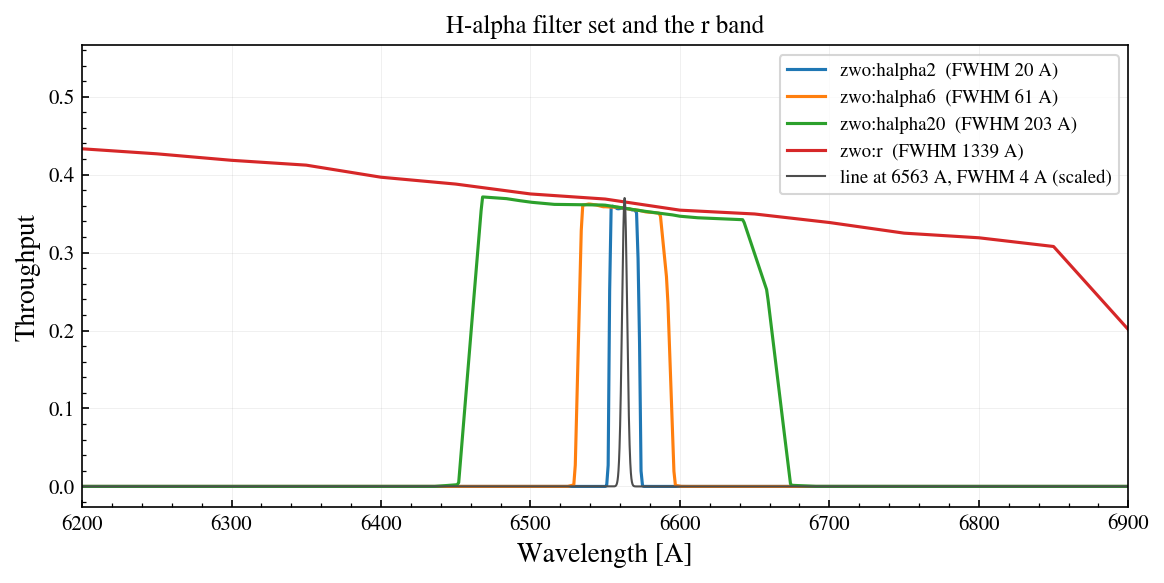

In [3]:
filters = ["zwo:halpha2", "zwo:halpha6", "zwo:halpha20", "zwo:r"]
line = [{"wave": LINE_WAVE, "flux": LINE_FLUX, "fwhm": 4}]     # erg/s/cm^2, Angstrom
sims = {f: Simulation.from_sensorfilter(f, get_scene("emission", mag=None, lines=line)) for f in filters}

w = np.arange(3000, 11000, 0.05)
fwhm = {}
print(f"{'filter':13s} {'throughput integral':>19s} {'rect. width':>12s} {'FWHM':>8s} {'T(line)':>10s} {'FWHM/2 as km/s':>15s}")
for f, s in sims.items():
    bp = s.sensor.bandpass
    T = bp(w).value; half = w[T >= T.max() / 2]
    fwhm[f] = half.max() - half.min()
    print(f"{f:13s} {bp.equivwidth().value:17.1f} A {bp.rectwidth().value:10.1f} A {fwhm[f]:6.1f} A {bp(LINE_WAVE).value:10.3f} "
          f"{fwhm[f] / 2 / 6563 * 2.998e5:12.0f}")

fig, ax = plt.subplots(figsize=(9, 4))
for f, s in sims.items():
    wcc_etc.plot_bandpass_mpl(s.sensor, ax=ax, label=f"{f}  (FWHM {fwhm[f]:.0f} A)")
sig = line[0]["fwhm"] / 2.355
ax.plot(w, 0.37 * np.exp(-0.5 * ((w - line[0]["wave"]) / sig) ** 2), color="0.3", lw=1, label=f"line at {LINE_WAVE:g} A, FWHM 4 A (scaled)")
ax.set(xlim=(6200, 6900), title="H-alpha filter set and the r band")
ax.legend(fontsize=9)
plt.show()

## 2. A pure emission-line source

An unresolved emission line with no continuum. The measured filter throughput at the selected wavelength sets the collected line photons: lying inside a filter does not guarantee equal throughput. This is an integrated point-source flux, not a diffuse surface-brightness limit.


In [4]:
t = EXPOSURE
for f, s in sims.items():
    print(f"{f:13s}: SNR = {s.get_image_snr(t, n_reads=R_READS if f == "zwo:r" else 1, warn=False)['snr']:5.1f}")

[wcc_etc] note: even n_pixels is rounded up by 1 to center the PSF peak (shown once).


zwo:halpha2  : SNR =  42.6
zwo:halpha6  : SNR =  42.5
zwo:halpha20 : SNR =  42.4


zwo:r        : SNR =  17.1


## 3. The same line on a stellar continuum

Now the line sits on the nucleus of a G5V-like continuum source (a point-source 'host') and the
continuum photon noise grows with filter width. SNR of the line in 300 s versus continuum magnitude.
Saturated points are omitted. The r image is split into `R_READS` reads; narrowband images use one read. This makes the default off-band continuum measurement unsaturated but adds read noise, which belongs in the comparison.


zwo:halpha2  : SNR at continuum V = 15 / 18 / 21:   6.3 /  21.7 /  39.2


zwo:halpha6  : SNR at continuum V = 15 / 18 / 21:   nan /  13.4 /  33.9


zwo:halpha20 : SNR at continuum V = 15 / 18 / 21:   nan /   7.5 /  24.7


zwo:r        : SNR at continuum V = 15 / 18 / 21:   nan /   2.7 /   9.1


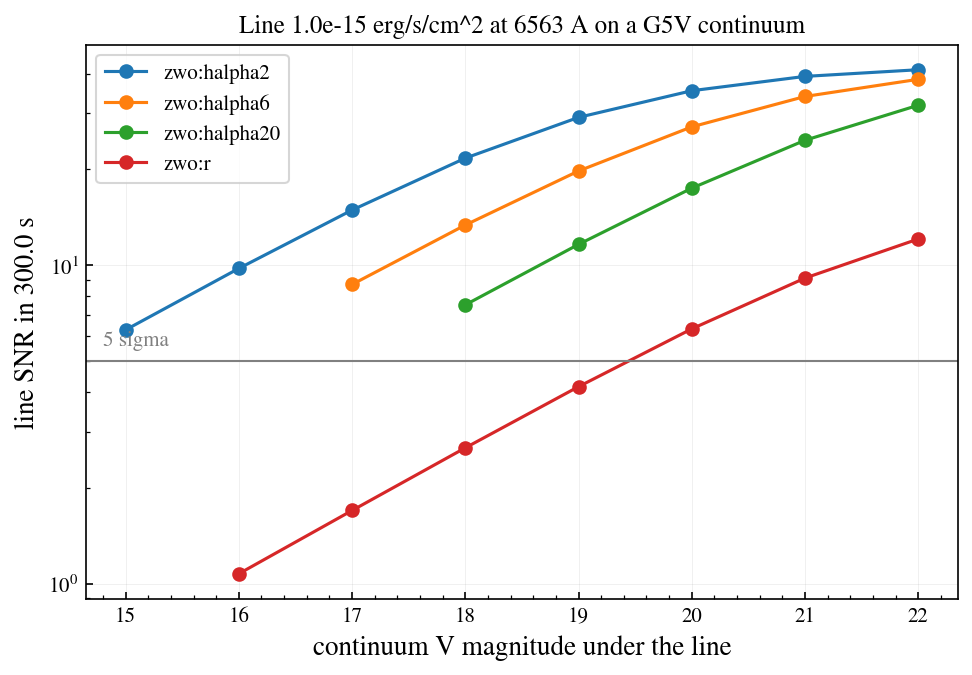

In [5]:
host_mags = np.arange(13, 22.5, 1.0)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for f in filters:
    s = Simulation.from_sensorfilter(f, get_scene("emission", mag=None, lines=line, host="G5V", host_prop={"mag": 17, "bandpass": "johnson_v", "magsys": "vegamag"}))
    snr = []
    for m in host_mags:
        s.update(host__mag=float(m))
        result = s.get_image_snr(t, n_reads=R_READS if f == "zwo:r" else 1, warn=False)
        snr.append(np.nan if result["saturated"] else result["snr"])
    ax.semilogy(host_mags, snr, "o-", label=f)
    print(f"{f:13s}: SNR at continuum V = 15 / 18 / 21: {snr[2]:5.1f} / {snr[5]:5.1f} / {snr[8]:5.1f}")
ax.axhline(5, color="0.5", lw=1); ax.text(0.02, 5.6, "5 sigma", transform=ax.get_yaxis_transform(), color="0.5")
ax.set(xlabel="continuum V magnitude under the line", ylabel=f"line SNR in {t} s",
       title=f"Line {LINE_FLUX:.1e} erg/s/cm^2 at {LINE_WAVE:g} A on a G5V continuum")
ax.legend()
plt.show()

## 4. Limiting line flux and the cost of continuum subtraction

The continuum normalization is explicitly Johnson V/Vega. An independent r image is scaled by the continuum count ratio k. The difference signal is L_N − k L_r, and its variance is Var(N) + k² Var(r), including line photons in both images. The scale factor is assumed known exactly; its uncertainty and morphology mismatch are omitted. A broadband detection alone does not identify H-alpha emission.


In [6]:
fluxes = np.logspace(-17, -14, 13)
for f in filters:
    s = Simulation.from_sensorfilter(f, get_scene("emission", mag=None, lines=line, host="G5V", host_prop={"mag": CONTINUUM_V, "bandpass": "johnson_v", "magsys": "vegamag"}))
    snr = []
    for fl in fluxes:
        s.update(source__lines=[{"wave": LINE_WAVE, "flux": float(fl), "fwhm": 4}])
        result = s.get_image_snr(t, n_reads=R_READS if f == "zwo:r" else 1, warn=False)
        snr.append(np.nan if result["saturated"] else result["snr"])
    if not (np.all(np.isfinite(snr)) and np.all(np.asarray(snr) > 0) and snr[0] < 5 < snr[-1] and np.all(np.diff(snr) > 0)):
        print(f"{f}: no finite, positive, monotonic bracket for SNR=5"); continue
    print(f"{f:13s}: 5 sigma line flux = {10 ** np.interp(np.log10(5), np.log10(snr), np.log10(fluxes)):.1e} erg/s/cm^2")

print(f"\nContinuum subtraction: line {LINE_FLUX:.1e} erg/s/cm^2 at {LINE_WAVE:g} A, V={CONTINUUM_V:g}, {t:g} s each:")
r_cont = Simulation.from_sensorfilter("zwo:r", get_scene("G5V", mag=CONTINUUM_V, bandpass="johnson_v", magsys="vegamag")).get_image_snr(t, n_reads=R_READS, warn=False)
r_total = Simulation.from_sensorfilter("zwo:r", get_scene("emission", mag=None, lines=line, host="G5V", host_prop={"mag": CONTINUUM_V, "bandpass": "johnson_v", "magsys": "vegamag"})).get_image_snr(t, n_reads=R_READS, warn=False)
for f in filters[:3]:
    n = Simulation.from_sensorfilter(f, get_scene("emission", mag=None, lines=line, host="G5V", host_prop={"mag": CONTINUUM_V, "bandpass": "johnson_v", "magsys": "vegamag"})).get_image_snr(t, warn=False)
    c_n = Simulation.from_sensorfilter(f, get_scene("G5V", mag=CONTINUUM_V, bandpass="johnson_v", magsys="vegamag")).get_image_snr(t, warn=False)
    if any(result["saturated"] for result in (n, c_n, r_cont, r_total)):
        print(f"{f}: continuum subtraction invalid (saturation); change read split or source brightness")
        continue
    k = c_n["signal_e"] / r_cont["signal_e"]
    sig_sub = np.sqrt(n["noise_e"] ** 2 + k ** 2 * r_total["noise_e"] ** 2)
    print(f"{f:13s}: k = {k:.4f}, line SNR {n['snr']:5.1f} with known continuum -> {(n['signal_e'] - k * r_total['signal_e']) / sig_sub:5.1f} after subtracting the scaled r image")


zwo:halpha2  : 5 sigma line flux = 2.1e-16 erg/s/cm^2


zwo:halpha6  : 5 sigma line flux = 3.6e-16 erg/s/cm^2


zwo:halpha20 : 5 sigma line flux = 6.6e-16 erg/s/cm^2


zwo:r        : 5 sigma line flux = 1.9e-15 erg/s/cm^2

Continuum subtraction: line 1.0e-15 erg/s/cm^2 at 6563 A, V=18, 300 s each:


zwo:halpha2  : k = 0.0108, line SNR  21.7 with known continuum ->  21.4 after subtracting the scaled r image


zwo:halpha6  : k = 0.0348, line SNR  13.4 with known continuum ->  12.7 after subtracting the scaled r image


zwo:halpha20 : k = 0.1186, line SNR   7.5 with known continuum ->   6.2 after subtracting the scaled r image


## Reference-run takeaway (default scene)

A narrower filter suppresses continuum photons and can improve line sensitivity when it transmits the line. Compare the current printed filter transmission, line-flux limits and continuum-subtraction results above. The r exposure is split into 30 reads by default because a single 300 s exposure of the V=18 continuum saturates; those additional reads add noise. Saturated continuum-sweep samples are excluded.

The difference signal includes line leakage into r and noise in both images. Scale-factor uncertainty is still omitted. Wider H-alpha filters can retain throughput for sources with larger velocity offsets or widths; being inside a nominal filter width does not establish equal throughput. These are unresolved-source integrated line-flux calculations, not diffuse-gas surface-brightness limits or completeness estimates.


## Try this

1. Set CONTINUUM_V to 19. Compare the limiting line flux and continuum-subtracted SNR.
2. Set LINE_WAVE to 6573. Compare filter throughput and line SNR.

**Extension:** Convert wavelength shifts to velocity and distinguish point sources from diffuse gas.

Bring back one figure, the requested and achieved metric, an observing decision, and the main limitation.
